## **Importing Libraries**

In [ ]:
%%capture
!pip install mordred
!pip install rdkit


In [ ]:
# Importing Libraries
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, AllChem

import mordred
from mordred import Calculator, descriptors


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', 2000)
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, BayesianRidge, ElasticNetCV, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

In [ ]:
sns.set(style='whitegrid')

## **Dataset and descriptors**

Youtube videos for generating molecular descriptors from SMILES

> https://youtu.be/EeOCGvy2pmQ


> https://youtu.be/Sgh-qJVYI5Q





In [ ]:
data = pd.read_csv('delaney.csv')
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [ ]:
mol_list = []

for smile in data['SMILES']:
  mol = Chem.MolFromSmiles(smile)
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  mol_list.append(mol)

data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)

In [ ]:
# Creating a descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=False)

all_desc = calc.pandas(data['Mol'])

In [ ]:
df_index = data[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']]

In [ ]:
df = pd.concat([df_index, all_desc], axis=1)
df.head()

In [ ]:
df.to_excel('delaney_mordred.xlsx', index=None)

## **Loading the Dataset**

In [ ]:
df = pd.read_excel('delaney_mordred.xlsx')

In [ ]:
df.head()

Compound ID               SMILES  \
0       1,1,1,2-Tetrachloroethane       ClCC(Cl)(Cl)Cl   
1           1,1,1-Trichloroethane         CC(Cl)(Cl)Cl   
2       1,1,2,2-Tetrachloroethane       ClC(Cl)C(Cl)Cl   
3           1,1,2-Trichloroethane           ClCC(Cl)Cl   
4  1,1,2-Trichlorotrifluoroethane  FC(F)(Cl)C(F)(Cl)Cl   

   measured log(solubility:mol/L)       ABC     ABCGG  nAcid  nBase   SpAbs_A  \
0                           -2.18  4.012290  4.284816      0      0  5.818626   
1                           -2.00  3.464102  3.464102      0      0  4.000000   
2                           -1.74  3.932653  4.244375      0      0  6.000000   
3                           -1.48  3.047207  3.305183      0      0  5.226252   
4                           -3.04  5.808525  6.167293      0      0  7.211103   

    SpMax_A  SpDiam_A    SpAD_A   SpMAD_A   LogEE_A     VE1_A     VE2_A  \
0  2.074313  4.148627  5.818626  0.969771  2.626363  2.285500  0.380917   
1  2.000000  4.000000  4.000000  0.800000  2.444466  2.121320  0.424264   
2  2.000000  4.000000  6.000000  1.000000  2.610845  2.309401  0.384900   
3  1.847759  3.695518  5.226252  1.045250  2.408576  2.130986  0.426197   
4  2.302776  4.605551  7.211103  0.901388  2.947233  2.602595  0.325324   

      VE3_A      VR1_A     VR2_A     VR3_A  nAromAtom  nAromBond  nAtom  \
0  0.315759  11.637367  1.939561  1.943396          0          0      8   
1  0.058892   8.000000  1.600000  1.386294          0          0      8   
2  0.326163  11.530010  1.921668  1.934128          0          0      8   
3  0.063438   8.629874  1.725975  1.462083          0          0      8   
4  0.733365  17.881697  2.235212  2.660634          0          0      8   

   nHeavyAtom  nSpiro  nBridgehead  nHetero  nH  nB  nC  nN  nO  nS  nP  nF  \
0           6       0            0        4   2   0   2   0   0   0   0   0   
1           5       0            0        3   3   0   2   0   0   0   0   0   
2           6       0            0        4   2   0   2   0   0   0   0   0   
3           5       0            0        3   3   0   2   0   0   0   0   0   
4           8       0            0        6   0   0   2   0   0   0   0   3   

   nCl  nBr  nI  nX      ATS0dv      ATS1dv      ATS2dv      ATS3dv  ATS4dv  \
0    4    0   0   4   22.419753   18.888889    9.592593    1.814815     0.0   
1    3    0   0   3   18.814815   13.333333    4.148148    0.000000     0.0   
2    4    0   0   4   20.419753   18.333333   10.543210    2.419753     0.0   
3    3    0   0   3   14.814815   12.222222    6.049383    1.209877     0.0   
4    3    0   0   6  180.814815  109.333333  164.716049  126.432099     0.0   

   ATS5dv  ATS6dv  ATS7dv  ATS8dv  ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  \
0     0.0     0.0     0.0     0.0     26     26     24      9      0      0   
1     0.0     0.0     0.0     0.0     23     19     21      9      0      0   
2     0.0     0.0     0.0     0.0     24     27     24      9      0      0   
3     0.0     0.0     0.0     0.0     19     21     21      9      0      0   
4     0.0     0.0     0.0     0.0     38     40     30      9      0      0   

   ATS6d  ATS7d  ATS8d       ATS0s      ATS1s       ATS2s       ATS3s ATS4s  \
0      0      0      0   13.055908  11.939815   19.361568    13.50663     0   
1      0      0      0   13.995056  13.546296    20.25663   12.111111     0   
2      0      0      0   12.798964  11.621399   18.848041   13.626124     0   
3      0      0      0   12.460334  11.940329    18.19151   12.350099     0   
4      0      0      0  200.557556  36.608796  143.918877  185.448865     0   

  ATS5s ATS6s ATS7s ATS8s  ATS0Z  ATS1Z  ATS2Z  ATS3Z  ATS4Z  ATS5Z  ATS6Z  \
0     0     0     0     0   1230    456   1322    969      0      0      0   
1     0     0     0     0    942    360   1194    153      0      0      0   
2     0     0     0     0   1230    456   1066   1225      0      0      0   
3     0     0     0     0    942    360    682    665      0      0     

In [ ]:
df.shape

(1144, 1829)

## **Data Preprocessing**
https://youtu.be/2esT6rYuV_g


1.   Removing missing values/non-numerical values
2.   Remove constant values
3.   Remove highly correlated values





In [ ]:
df.head()

In [ ]:
data = df.iloc[:,3:]

In [ ]:
data.head()

ABC     ABCGG  nAcid  nBase   SpAbs_A   SpMax_A  SpDiam_A    SpAD_A  \
0  4.012290  4.284816      0      0  5.818626  2.074313  4.148627  5.818626   
1  3.464102  3.464102      0      0  4.000000  2.000000  4.000000  4.000000   
2  3.932653  4.244375      0      0  6.000000  2.000000  4.000000  6.000000   
3  3.047207  3.305183      0      0  5.226252  1.847759  3.695518  5.226252   
4  5.808525  6.167293      0      0  7.211103  2.302776  4.605551  7.211103   

    SpMAD_A   LogEE_A     VE1_A     VE2_A     VE3_A      VR1_A     VR2_A  \
0  0.969771  2.626363  2.285500  0.380917  0.315759  11.637367  1.939561   
1  0.800000  2.444466  2.121320  0.424264  0.058892   8.000000  1.600000   
2  1.000000  2.610845  2.309401  0.384900  0.326163  11.530010  1.921668   
3  1.045250  2.408576  2.130986  0.426197  0.063438   8.629874  1.725975   
4  0.901388  2.947233  2.602595  0.325324  0.733365  17.881697  2.235212   

      VR3_A  nAromAtom  nAromBond  nAtom  nHeavyAtom  nSpiro  nBridgehead  \
0  1.943396          0          0      8           6       0            0   
1  1.386294          0          0      8           5       0            0   
2  1.934128          0          0      8           6       0            0   
3  1.462083          0          0      8           5       0            0   
4  2.660634          0          0      8           8       0            0   

   nHetero  nH  nB  nC  nN  nO  nS  nP  nF  nCl  nBr  nI  nX      ATS0dv  \
0        4   2   0   2   0   0   0   0   0    4    0   0   4   22.419753   
1        3   3   0   2   0   0   0   0   0    3    0   0   3   18.814815   
2        4   2   0   2   0   0   0   0   0    4    0   0   4   20.419753   
3        3   3   0   2   0   0   0   0   0    3    0   0   3   14.814815   
4        6   0   0   2   0   0   0   0   3    3    0   0   6  180.814815   

       ATS1dv      ATS2dv      ATS3dv  ATS4dv  ATS5dv  ATS6dv  ATS7dv  ATS8dv  \
0   18.888889    9.592593    1.814815     0.0     0.0     0.0     0.0     0.0   
1   13.333333    4.148148    0.000000     0.0     0.0     0.0     0.0     0.0   
2   18.333333   10.543210    2.419753     0.0     0.0     0.0     0.0     0.0   
3   12.222222    6.049383    1.209877     0.0     0.0     0.0     0.0     0.0   
4  109.333333  164.716049  126.432099     0.0     0.0     0.0     0.0     0.0   

   ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  ATS6d  ATS7d  ATS8d       ATS0s  \
0     26     26     24      9      0      0      0      0      0   13.055908   
1     23     19     21      9      0      0      0      0      0   13.995056   
2     24     27     24      9      0      0      0      0      0   12.798964   
3     19     21     21      9      0      0      0      0      0   12.460334   
4     38     40     30      9      0      0      0      0      0  200.557556   

       ATS1s       ATS2s       ATS3s ATS4s ATS5s ATS6s ATS7s ATS8s  ATS0Z  \
0  11.939815   19.361568    13.50663     0     0     0     0     0   1230   
1  13.546296    20.25663   12.111111     0     0     0     0     0    942   
2  11.621399   18.848041   13.626124     0     0     0     0     0   1230   
3  11.940329    18.19151   12.350099     0     0     0     0     0    942   
4  36.608796  143.918877  185.448865     0     0     0     0     0   1182   

   ATS1Z  ATS2Z  ATS3Z  ATS4Z  ATS5Z  ATS6Z  ATS7Z  ATS8Z        ATS0m  \
0    456   1322    969      0      0      0      0      0  5317.370370   
1    360   1194    153      0      0      0      0      0  4061.683934   
2    456   1066   1225      0      0      0      0      0  5317.370370   
3    360    682    665      0      0      0      0      0  4061.683934   
4    504   1450   1505      0      0      0      0      0  5141.453714   

         ATS1m        ATS2m        ATS3m  ATS4m  ATS5m  ATS6m  ATS7m  ATS8m  \
0  1871.638097  5569.964740  3984.509100    0.0    0.0    0.0    0.0    0.0   
1  1457.955235  5086.846806   321.602400    0.0    0.0    0.0    0.0    0.0   
2  1871.638097  4383.713376  5170.760464   

In [ ]:
data.isnull().sum().sum()

0

In [ ]:
column_num = []
column_bool = []
for column in data.columns:
  column_type = data[column].dtype
  if column_type == 'object':
      pass
  elif column_type =='bool':
      column_bool.append(column)
  else:
      column_num.append(column)

In [ ]:
len(column_num)

1271

In [ ]:
column_bool

['Lipinski', 'GhoseFilter']

In [ ]:
data['GhoseFilter'].unique()

In [ ]:
gf = data['GhoseFilter'].astype(int)
gf.value_counts().plot(kind='bar')


In [ ]:
data = data[column_num + column_bool]

In [ ]:
data.shape

(1144, 1273)

In [ ]:
def remove_constant_values(data):
    return [e for e in data.columns if data[e].nunique() == 1]

drop_col = remove_constant_values(data)
#drop_col

new_df_columns = [e for e in data.columns if e not in drop_col]
new_df = data[new_df_columns]
new_df

ABC      ABCGG  nBase    SpAbs_A   SpMax_A  SpDiam_A     SpAD_A  \
0      4.012290   4.284816      0   5.818626  2.074313  4.148627   5.818626   
1      3.464102   3.464102      0   4.000000  2.000000  4.000000   4.000000   
2      3.932653   4.244375      0   6.000000  2.000000  4.000000   6.000000   
3      3.047207   3.305183      0   5.226252  1.847759  3.695518   5.226252   
4      5.808525   6.167293      0   7.211103  2.302776  4.605551   7.211103   
...         ...        ...    ...        ...       ...       ...        ...   
1139  10.943860  10.834541      0  19.178732  2.222674  4.445348  19.178732   
1140  13.848577  12.817957      0  21.491177  2.513161  4.873236  21.491177   
1141  17.872588  14.857897      0  29.447228  2.482065  4.964130  29.447228   
1142  17.730457  15.492423      0  27.142711  2.437677  4.875353  27.142711   
1143   9.520558   8.873882      0  15.211804  2.278414  4.556827  15.211804   

       SpMAD_A   LogEE_A     VE1_A     VE2_A     VE3_A       VR1_A     VR2_A  \
0     0.969771  2.626363  2.285500  0.380917  0.315759   11.637367  1.939561   
1     0.800000  2.444466  2.121320  0.424264  0.058892    8.000000  1.600000   
2     1.000000  2.610845  2.309401  0.384900  0.326163   11.530010  1.921668   
3     1.045250  2.408576  2.130986  0.426197  0.063438    8.629874  1.725975   
4     0.901388  2.947233  2.602595  0.325324  0.733365   17.881697  2.235212   
...        ...       ...       ...       ...       ...         ...       ...   
1139  1.198671  3.613477  3.333258  0.208329  1.673954   92.824702  5.801544   
1140  1.193954  3.821470  3.668785  0.203821  1.887647  105.790793  5.877266   
1141  1.280314  4.064996  4.121171  0.179181  2.249046  175.486940  7.629867   
1142  1.180118  4.049881  4.179173  0.181703  2.263023  152.094429  6.612801   
1143  1.170139  3.450538  3.265105  0.251162  1.445656   57.381559  4.413966   

      nAromAtom  nAromBond  nAtom  nHeavyAtom  nSpiro  nBridgehead  nHetero  \
0             0          0      8           6       0            0        4   
1             0          0      8           5       0            0        3   
2             0          0      8           6       0            0        4   
3             0          0      8           5       0            0        3   
4             0          0      8           8       0            0        6   
...         ...        ...    ...         ...     ...          ...      ...   
1139          0          0     34          16       0            0        8   
1140          6          6     27          18       0            0        6   
1141         16         17     39          23       0            0        4   
1142         12         12     38          23       0            0        8   
1143          6          6     26          13       0            0        3   

      nH  nC  nN  nO  nS  nP  nF  nCl  nBr  nI  nX      ATS0dv      ATS1dv  \
0      2   2   0   0   0   0   0    4    0   0   4   22.419753   18.888889   
1      3   2   0   0   0   0   0    3    0   0   3   18.814815   13.333333   
2      2   2   0   0   0   0   0    4    0   0   4   20.419753   18.333333   
3      3   2   0   0   0   0   0    3    0   0   3   14.814815   12.222222   
4      0   2   0   0   0   0   3    3    0   0   6  180.814815  109.333333   
...   ..  ..  ..  ..  ..  ..  ..  ...  ...  ..  ..         ...         ...   
1139  18   8   1   4   2   1   0    0    0   0   0  198.197531   90.037037   
1140   9  12   1   3   0   0   0    2    0   0   2  271.209877  272.222222   
1141  16  19   0   4   0   0   0    0    0   0   0  340.000000  333.000000   
1142  15  15   2   4   1   0   0    1    0   0   1  334.049383  269.777778   
1143  13  10   1   2   0   0   0    0    0   0   0  182.000000  172.000000   

          ATS2dv      ATS3dv      ATS4dv      ATS5dv      ATS6dv      ATS7dv  \
0       9.592593    1.814815    0.000000    0.000000    0.000000    0.000000   
1       4.148148    0.000000    0.000000    0.000000    

In [ ]:
len(drop_col)

153

In [ ]:

# To calclulate  Correlation and remove highly  correlated columns
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [ ]:
# Dropping highly correlated Features
corr_features = correlation(new_df, 0.80)
print("No. of features to drop : ",len(set(corr_features)))

new_df.drop(corr_features,axis=1,inplace=True)

No. of features to drop :  839


In [ ]:
new_df.shape

(1144, 281)

In [ ]:
new_df.head()

In [ ]:
new_df['Lipinski'] = df["Lipinski"].astype(int)
new_df['GhoseFilter'] = df["GhoseFilter"].astype(int)

In [ ]:
new_df.head()

,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007122,0.330754,0.551252,183.331218,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587931,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.006067,0.523051,0.419031,0.126253,0.052579,-0.396607,-0.088052,0.436703,0.176355,-0.121027,-0.111853,-0.109321,0.030779,0.031542,-0.077838,-0.135739,0.176945,0.006169,9.368045,1.294557,2.961506,0.482696,0.013874,-0.310771,-0.444708,1.341090,-1.309609,0.614539,-0.271620,0.652980,-1.073352,0.796019,-0.150769,0.028099,-0.470898,0.678911,-0.308817,0.054015,0.174031,-0.055465,-0.327701,0.465231,-0.295556,0.227792,-0.047366,-0.017921,-0.149382,-0.072866,-0.002447,-0.072585,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.604444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.351852,117.75,8.932912,164.102494,0.043231,0.0,0.0,0.0,0.0,0.0,-1.256944,-5.935185,1.145833,0.0,0.0,0.0,0.0,0.0,-1.6875,1.265625,0.0,0.0,0.0,0.0,0.0,-5.0625,377.25,-570.9375,0.0,0

In [ ]:
df_final = pd.concat([df.iloc[:, :3], new_df], axis=1)
df_final.head()

In [ ]:
df_final.shape

In [ ]:
# df_final.to_csv('delaney_mordred_truncated.csv', index=None)

## **Data Analysis**

In [ ]:
df_final= pd.read_csv('delaney_mordred_truncated.csv')

In [ ]:
df_final.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007122,0.330754,0.551252,183.331218,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587931,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.006067,0.523051,0.419031,0.126253,0.052579,-0.396607,-0.088052,0.436703,0.176355,-0.121027,-0.111853,-0.109321,0.030779,0.031542,-0.077838,-0.135739,0.176945,0.006169,9.368045,1.294557,2.961506,0.482696,0.013874,-0.310771,-0.444708,1.341090,-1.309609,0.614539,-0.271620,0.652980,-1.073352,0.796019,-0.150769,0.028099,-0.470898,0.678911,-0.308817,0.054015,0.174031,-0.055465,-0.327701,0.465231,-0.295556,0.227792,-0.047366,-0.017921,-0.149382,-0.072866,-0.002447,-0.072585,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.604444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.351852,117.75,8.932912,164.102494,0.0

In [ ]:
# change the target column name
df_final.rename(columns={'measured log(solubility:mol/L)' : 'Log_sol'}, inplace=True)

In [ ]:
df_final.head()

,Compound ID,SMILES,Log_sol,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007122,0.330754,0.551252,183.331218,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587931,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.006067,0.523051,0.419031,0.126253,0.052579,-0.396607,-0.088052,0.436703,0.176355,-0.121027,-0.111853,-0.109321,0.030779,0.031542,-0.077838,-0.135739,0.176945,0.006169,9.368045,1.294557,2.961506,0.482696,0.013874,-0.310771,-0.444708,1.341090,-1.309609,0.614539,-0.271620,0.652980,-1.073352,0.796019,-0.150769,0.028099,-0.470898,0.678911,-0.308817,0.054015,0.174031,-0.055465,-0.327701,0.465231,-0.295556,0.227792,-0.047366,-0.017921,-0.149382,-0.072866,-0.002447,-0.072585,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.604444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.351852,117.75,8.932912,164.102494,0.043231,0.0,0.0,0.0,0.0,0

In [ ]:
df_final['Log_sol'].describe()

count    1144.000000
mean       -3.057997
std         2.096502
min       -11.600000
25%        -4.332250
50%        -2.870500
75%        -1.600000
max         1.580000
Name: Log_sol, dtype: float64

In [ ]:
df_final['Log_sol'].argmin()

116

In [ ]:
df_final.iloc[116,:5]

Compound ID                         2,2',3,3',4,4',5,5',6,6'-PCB
SMILES         Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...
Log_sol                                                    -11.6
ABC                                                    16.831632
nBase                                                          0
Name: 116, dtype: object

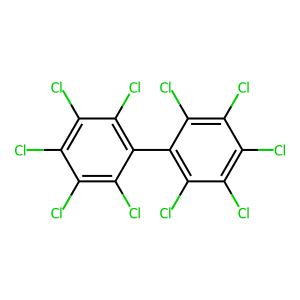

In [ ]:
mol = Chem.MolFromSmiles(df_final['SMILES'][116])
Draw.MolToImage(mol)

In [ ]:
df_final['Log_sol'].argmax()

361

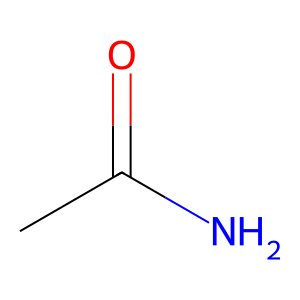

In [ ]:
mol = Chem.MolFromSmiles(df_final['SMILES'][361])
Draw.MolToImage(mol)

In [ ]:
df_final['Compound ID'][361]

<Figure size 400x600 with 0 Axes>

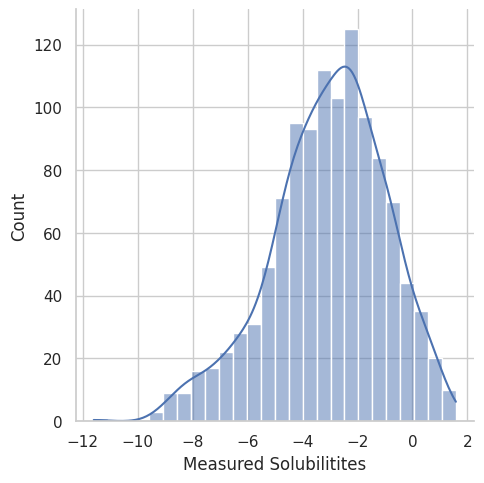

In [ ]:
plt.figure(figsize=(4,6))
sns.displot(df_final, x='Log_sol', kde=True)
plt.xlabel('Measured Solubilitites');
plt.savefig('dist_solubility.png', dpi=200, bbox_inches='tight')

In [ ]:
corr = df_final.corr()
corr

,Log_sol,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
Log_sol,1.000000,-0.587292,0.009436,-0.400888,-0.042746,-0.489810,0.009736,-0.095359,-0.179433,0.066841,0.059156,-0.061972,-0.081202,-0.127937,-0.399321,-0.035298,-0.017184,-0.459590,-0.044767,-0.075770,-0.000651,0.484488,-0.007366,-0.022459,0.033025,-0.005921,-0.063347,0.055003,-0.251400,-0.136296,-0.069324,0.045084,0.100243,0.113411,0.091624,0.086496,-0.083580,0.157898,0.234003,0.224319,0.173496,0.023859,-0.043903,-0.172014,-0.140773,-0.002663,0.082909,0.116975,0.203553,-0.006384,0.097382,-0.235124,-0.060179,-0.076672,0.100385,0.139165,0.186926,0.060701,0.013337,-0.153374,0.000660,0.027871,0.055575,-0.001550,0.006709,0.137679,-0.149955,-0.095963,-0.048922,0.051971,0.123415,0.081283,0.018429,0.019280,-0.211371,-0.077118,-0.021490,-0.032876,-0.196674,-0.251458,-0.109734,-0.070623,0.218447,0.203393,0.251753,0.120214,0.070777,0.180441,0.072270,0.140584,-0.280094,-0.140636,0.480060,0.253453,-0.061760,-0.035014,0.408654,0.627965,0.465201,-0.432773,-0.134041,-0.016924,0.099221,-0.518606,-0.020546,-0.162640,-0.216889,-0.123942,0.232514,-0.097353,-0.159150,-0.156156,-0.075765,-0.011673,0.071495,0.005334,-0.028907,-0.063551,-0.483985,-0.289508,0.133202,0.015074,0.029107,0.048935,-0.038680,-0.017509,0.081737,-0.093514,-0.022719,0.062146,0.177421,-0.055227,-0.030371,0.031218,-0.107818,-0.037076,0.019996,0.024952,-0.010519,-0.117250,-0.055631,-0.327980,-0.284784,-0.364286,-0.317189,-0.135497,0.384331,-0.110615,-0.232981,0.218084,0.083560,-0.071384,0.358809,0.251745,0.863686,-0.269496,0.211972,0.012202,0.195144,0.133936,-0.057218,0.188927,-0.139945,-0.225139,0.004756,-0.126843,0.057920,-0.113883,0.401460,0.083640,0.160161,-0.083139,0.391642,-0.270939,0.041773,-0.463958,0.026212,0.086752,-0.221329,-0.157686,0.155939,0.228335,-0.376114,0.021704,-0.188329,0.494190,0.168860,-0.556947,0.356850,-0.036889,0.154055,-0.027354,0.391361,0.039618,0.044307,-0.019973,-0.154690,-0.148647

In [ ]:
corr_sorted = abs(corr[['Log_sol']]).sort_values(by ='Log_sol', ascending=False)
corr_sorted = corr_sorted.iloc[1:5, :]
corr_sorted.rename(columns={'Log_sol' : 'correlation_coef'}, inplace=True)
corr_sorted

,correlation_coef
FilterItLogS,0.863686
PEOE_VSA6,0.705928
RNCG,0.627965
ABC,0.587292


Text(0, 0.5, 'Correlation Coefficient')

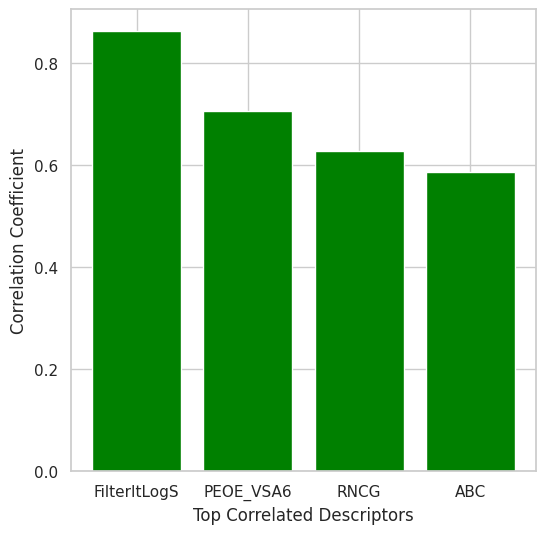

In [ ]:
fig = plt.figure(1, figsize=(6,6))
ax1 = fig.add_subplot(111)
plt.bar(x = corr_sorted.index, height = corr_sorted['correlation_coef'], color = 'green')
ax1.set_xlabel('Top Correlated Descriptors')
ax1.set_ylabel('Correlation Coefficient')

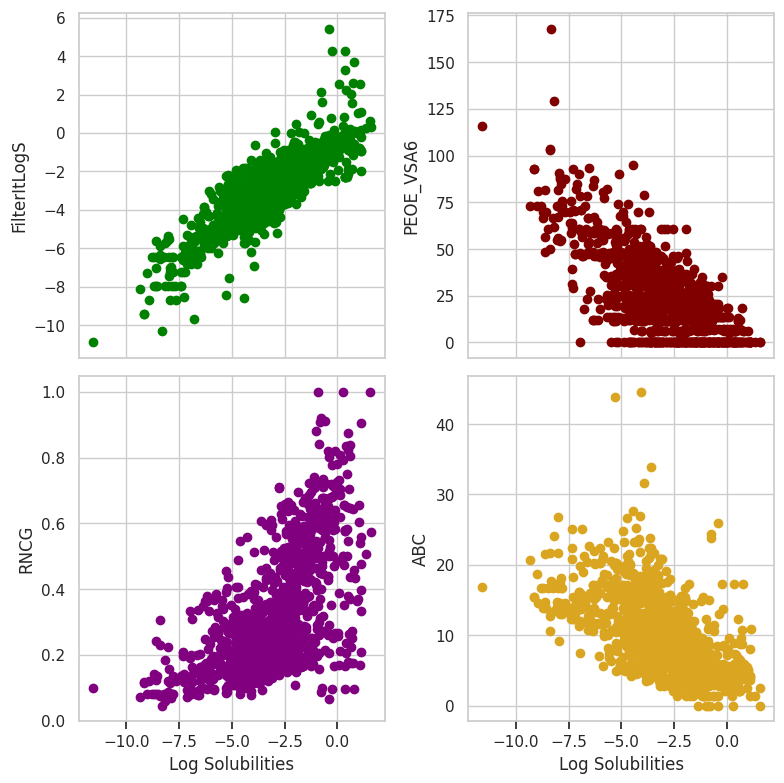

In [ ]:
plt.figure(figsize=(8,8))
color = ['green', 'maroon', 'purple', 'goldenrod']
for index, col in enumerate(['FilterItLogS', 'PEOE_VSA6', 'RNCG', 'ABC']):
  plt.subplot(2,2,index+1)
  plt.scatter(x = df_final['Log_sol'], y = df_final[col], color = color[index])
  plt.ylabel(col)
  plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
  if index>=2:
    plt.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    plt.xlabel('Log Solubilities')

plt.tight_layout()
plt.savefig('top_corr_des.png', dpi=200, bbox_inches='tight')

In [ ]:
# slice dataset based on 4 highly correlated descriptros
corr_4 = df_final[['FilterItLogS', 'PEOE_VSA6', 'RNCG', 'ABC', 'Log_sol']].corr()
corr_4

,FilterItLogS,PEOE_VSA6,RNCG,ABC,Log_sol
FilterItLogS,1.000000,-0.711077,0.473776,-0.563685,0.863686
PEOE_VSA6,-0.711077,1.000000,-0.385994,0.291474,-0.705928
RNCG,0.473776,-0.385994,1.000000,-0.573222,0.627965
ABC,-0.563685,0.291474,-0.573222,1.000000,-0.587292
Log_sol,0.863686,-0.705928,0.627965,-0.587292,1.000000


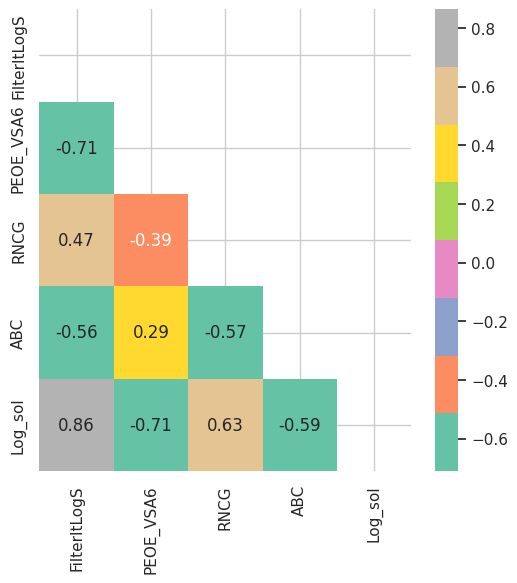

In [ ]:
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_4, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(6,6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_4, mask=mask, cmap='Set2', annot=True)

# save figure
plt.savefig('corr_matrix.png', dpi=200, bbox_inches='tight')

In [ ]:
# df_final = pd.read_csv('delaney_mordred_truncated.csv')

## **Model Selection**

# **Model Screening using Lazypredict**

In [ ]:
%%capture
!pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyRegressor

In [ ]:
y = df_final['Log_sol']
scaled_DF = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:,3:]), columns=([df_final.iloc[:,3:]]))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_DF, y, test_size=0.20, random_state=2)

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(predictions)

 21%|██▏       | 9/42 [00:14<00:55,  1.69s/it]

GammaRegressor model failed to execute
Some value(s) of y are out of the valid range of the loss 'HalfGammaLoss'.


 76%|███████▌  | 32/42 [00:34<00:03,  3.24it/s]

PoissonRegressor model failed to execute
Some value(s) of y are out of the valid range of the loss 'HalfPoissonLoss'.
QuantileRegressor model failed to execute
Solver interior-point is not anymore available in SciPy >= 1.11.0.


 98%|█████████▊| 41/42 [00:55<00:01,  1.71s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41638
[LightGBM] [Info] Number of data points in the train set: 915, number of used features: 254
[LightGBM] [Info] Start training from score -3.090472


100%|██████████| 42/42 [00:57<00:00,  1.37s/it]

                                                          Adjusted R-Squared  \
Model                                                                          
Lars                          3268065562345685332296742612073545621045248.00   
RANSACRegressor                                                        59.37   
MLPRegressor                                                           15.98   
GaussianProcessRegressor                                               13.50   
KernelRidge                                                            10.02   
DummyRegressor                                                          5.33   
LassoLars                                                               3.06   
Lasso                                                                   3.06   
TweedieRegressor                                                        2.98   
PassiveAggressiveRegressor                                              2.80   
ElasticNet                              

## **Model Screening using Cross-validation**
https://youtu.be/3mBYqTPE4A8

In [ ]:
y = df_final['Log_sol']

In [ ]:
scaled_DF = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:,3:]), columns=([df_final.iloc[:,3:]]))


In [ ]:
scaled_DF

,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,-1.05,-0.08,-2.07,-0.05,-1.00,-0.08,-0.12,0.22,-0.67,-0.84,-0.30,-0.19,-0.18,2.38,-0.19,-0.11,0.53,-1.04,1.54,2.67,-0.08,-0.36,-0.06,0.16,-0.10,0.02,-0.01,-1.02,-0.51,0.48,0.64,0.48,0.25,0.18,0.06,-0.39,0.94,0.64,0.35,0.23,0.07,-0.11,-0.53,0.35,-1.18,0.36,0.31,0.19,0.11,0.10,-0.00,0.17,-0.14,0.42,0.32,0.15,0.13,0.01,-0.01,-0.62,0.32,0.40,0.03,0.12,0.15,0.09,0.11,-0.23,0.78,0.12,0.03,0.03,0.04,-3.54,0.57,0.09,-1.28,-0.24,-0.51,0.53,0.08,-0.52,-0.32,-1.00,-0.03,0.10,0.19,1.86,-0.52,1.32,-0.19,2.08,1.63,-0.81,-0.18,-1.73,0.03,3.19,0.78,-1.04,-0.11,-0.62,-0.59,0.21,-0.57,-0.39,-0.33,1.49,-0.12,-0.12,2.32,1.87,-1.00,-0.19,-0.11,-0.34,-0.41,-0.83,-0.29,-0.26,-0.03,-0.42,-0.15,-0.14,-0.13,-0.32,-0.34,-0.21,-0.17,-0.37,-0.46,-0.14,-0.07,-0.20,-0.21,-0.10,-0.06,-0.15,0.10,0.09,-0.58,-1.81,-0.66,0.65,-2.21,-0.63,-0.56,-1.07,-0.64,0.24,-1.06,1.78,0.20,0.02,-0.40,1.60,-0.49,0.26,0.94,-0.03,0.77,0.05,-0.18,-0.38,-0.16,0.14,-1.09,1.29,0.47,0.23,0.13,0.70,-0.35,1.30,1.11,1.39,-0.32,-0.97,-1.33,2.91,-1.37,-0.03,-0.56,2.00,-2.16,1.93,-1.28,0.75,-1.82,2.56,-1.37,0.77,0.76,-0.33,-1.56,2.05,-1.74,1.37,0.31,-0.41,-0.91,-0.52,0.12,-0.41,-0.61,-0.50,-0.30,1.55,0.44,-1.14,-0.91,0.04,-0.55,-0.41,0.56,-0.36,0.05,-0.49,-0.64,-0.66,-0.57,-0.33,-0.51,-0.38,-0.04,-0.82,-0.77,-0.71,-0.68,-0.70,-0.79,-0.57,-0.40,-0.13,-0.17,-1.01,0.16,-0.40,-0.17,-0.06,-0.54,-0.07,-0.33,-0.24,-0.37,-0.24,-0.25,-0.54,-0.03,-0.05,-0.06,-0.20,-0.26,-0.07,-0.06,-0.35,-0.37,-0.19,-0.03,-0.20,-0.15,-0.24,-0.10,-0.39,-0.14,-0.15,-0.26,-0.10,-0.83,3.33,0.22,-1.86,-1.45,-1.14,-0.94,-0.79,-0.64,-0.47,-0.36,0.33,-0.84
1,-1.14,-0.08,-3.58,-0.05,-1.00,-0.08,-0.12,-0.13,-0.67,-0.84,-0.30,-0.19,-0.18,1.68,-0.19,-0.11,0.12,-1.17,1.03,1.68,0.22,-0.11,-0.06,0.16,-0.10,0.02,-0.01,-0.96,-0.51,0.43,0.64,0.48,0.25,0.18,0.06,-0.05,0.81,0.64,0.35,0.23,0.07,-0.11,-0.28,2.99,-3.18,0.36,0.31,0.19,0.11,0.10,-0.16,1.00,-0.91,0.42,0.32,0.15,0.1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_DF, y, test_size=0.20, random_state=45)

In [ ]:
X_train.shape

In [ ]:
for model in [LinearRegression, SVR, RandomForestRegressor, ExtraTreesRegressor]:
  m = model()
  m.fit(X_train, y_train)
  val = cross_val_score(m, X_train, y_train,  scoring='r2', cv=5)
  print(f'The CV r2 score for {model.__name__} is : {val.mean()}')

The CV r2 score for LinearRegression is : -8.83836066075683e+23
The CV r2 score for SVR is : 0.8387084855726918
The CV r2 score for RandomForestRegressor is : 0.887064492903621
The CV r2 score for ExtraTreesRegressor is : 0.9055344575708058


In [ ]:
m = LinearRegression()
m.fit(X_train, y_train)
val = cross_val_score(m, X_train, y_train,  scoring='r2', cv=5)
print(f'The CV r2 score for {model.__name__} is : {val}')

The CV r2 score for ExtraTreesRegressor is : [ 8.82850197e-01  8.37239096e-01  8.03715764e-01 -4.41918033e+24
  6.78846295e-01]


In [ ]:
for model in [LinearRegression, SVR, RandomForestRegressor, ExtraTreesRegressor]:
  m = model()
  m.fit(X_train, y_train)
  print(f'The r2 score for {model.__name__} for train set is : {m.score(X_train, y_train)}')
  print(f'The r2 score for {model.__name__} for test set is : {m.score(X_test, y_test)}')

The r2 score for LinearRegression for train set is : 0.9526138008130901
The r2 score for LinearRegression for test set is : 0.6235904754965749
The r2 score for SVR for train set is : 0.9379971632199458
The r2 score for SVR for test set is : 0.8303985454143927
The r2 score for RandomForestRegressor for train set is : 0.9844142714281696
The r2 score for RandomForestRegressor for test set is : 0.8660119047461443
The r2 score for ExtraTreesRegressor for train set is : 1.0
The r2 score for ExtraTreesRegressor for test set is : 0.9027238248880212


## **Feaure Reduction and Model Evaluation**
https://youtu.be/Q0B4lp1d48s

In [ ]:
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9849709730825061
The r2 score for test set is : 0.867977167635592


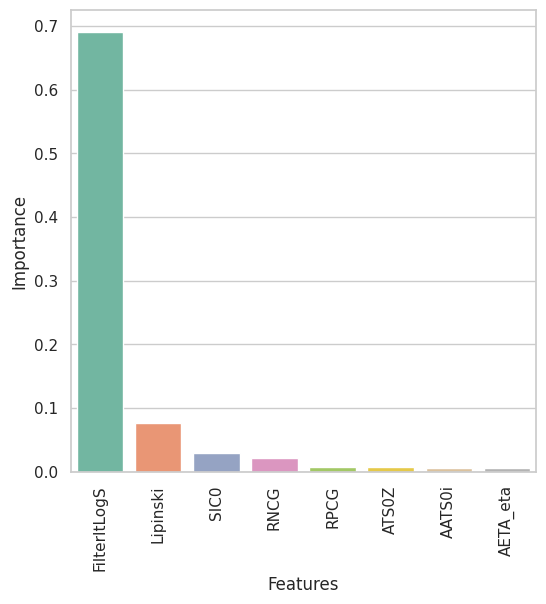

In [ ]:
# get importance
importance = rf.feature_importances_
# summarize feature importance
dicts = {
    'Features':[x for x in df_final.iloc[:,3:].columns],
    'Importance':importance
    }
DF_imp = pd.DataFrame(dicts)
DF_imp = DF_imp.sort_values('Importance',ascending=False)
DF_imp.to_excel('imp.xlsx', index=None)

# plot feature importance
top_desc_fi = DF_imp[:8]
plt.subplots(figsize=(6,6))
sns.barplot(data=top_desc_fi, x = 'Features', y='Importance', palette = 'Set2')
# plt.bar('Feature','Importance',data = DF_imp.iloc[:7,:])
plt.xticks(rotation = 90)
# plt.show()
plt.savefig('fi.png', dpi=200, bbox_inches='tight')

In [ ]:
DF_imp.head(7)

,Features,Importance
153,FilterItLogS,0.69
279,Lipinski,0.08
151,SIC0,0.03
96,RNCG,0.02
97,RPCG,0.01
16,ATS0Z,0.01
20,AATS0i,0.01


In [ ]:
DF_imp[:8]['Features'].values

array(['FilterItLogS', 'Lipinski', 'SIC0', 'RNCG', 'RPCG', 'ATS0Z',
       'AATS0i', 'AETA_eta'], dtype=object)

In [ ]:
df_final_8 = df_final[DF_imp[:8]['Features'].values]

In [ ]:
delaney_8_des = pd.concat([df_final_8, y], axis=1)

In [ ]:
delaney_8_des.head()

,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,AETA_eta,Log_sol
0,-2.79,1,0.50,0.33,0.55,1230,162.01,0.94,-2.18
1,-2.13,1,0.52,0.31,0.70,942,164.10,0.91,-2.00
2,-2.43,1,0.50,0.25,0.34,1230,162.01,0.90,-1.74
3,-2.15,1,0.52,0.37,0.36,942,164.10,0.78,-1.48
4,-2.66,1,0.52,0.28,0.53,1182,208.59,0.88,-3.04


 **Identify Optimal Descriptors: Sequential Addition**

In [ ]:
desc = delaney_8_des.columns.values
desc

array(['FilterItLogS', 'Lipinski', 'SIC0', 'RNCG', 'RPCG', 'ATS0Z',
       'AATS0i', 'AETA_eta', 'Log_sol'], dtype=object)

In [ ]:
y = delaney_8_des['Log_sol']
scores = []
for i in range(1,9):
  score = []
  df = delaney_8_des.iloc[:, :i]
  X = StandardScaler().fit_transform(df)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=45)
  rf = RandomForestRegressor(random_state=0)
  rf.fit(X_train, y_train)
  train = rf.score(X_train, y_train)
  score.append(train)
  test = rf.score(X_test, y_test)
  score.append(test)
  scores.append(score)



In [ ]:
scores

[[0.9625653723224489, 0.7126936223405373],
 [0.9645056944334274, 0.7159427489388839],
 [0.9754825203279608, 0.8128529542204412],
 [0.9803119981448878, 0.8278701976466968],
 [0.9815768192337464, 0.844555218997561],
 [0.9824713388165807, 0.8573345182898539],
 [0.9833176760507115, 0.8650514537343995],
 [0.9830908520920898, 0.8610225398427882]]

In [ ]:
df_seq = pd.DataFrame(scores, columns = ['Train', 'Test'], index = range(1,9)).round(3)

In [ ]:
pd.set_option('display.float_format', '{:.3f}'.format)
df_seq

,Train,Test
1,0.963,0.713
2,0.965,0.716
3,0.975,0.813
4,0.980,0.828
5,0.982,0.845
6,0.982,0.857
7,0.983,0.865
8,0.983,0.861


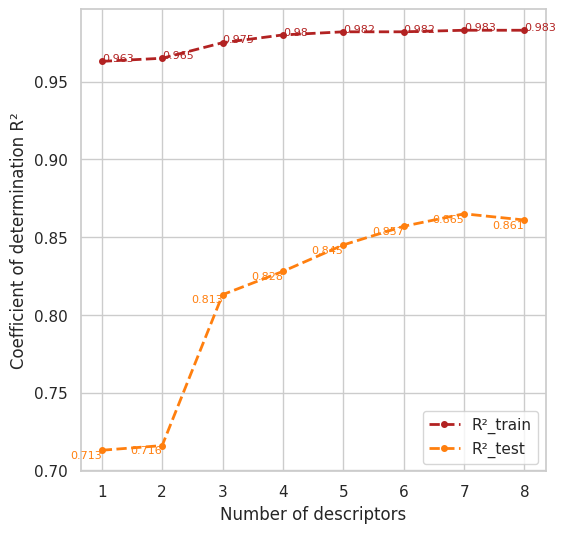

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
y1 = df_seq['Train']
y2 = df_seq['Test']
plt.plot(range(1,9),y1, label ='R\u00b2_train', marker='o', linestyle='dashed',
     linewidth=2, markersize=4, c = 'firebrick')
plt.plot(range(1,9),y2 , label= "R\u00b2_test", marker='o', linestyle='dashed',
     linewidth=2, markersize=4, c = '#ff7f0e' )

for i in range(1,9):
  ax.text(i, y1[i], y1[i], size=8, color='firebrick')

for i in range(1,9):
  ax.text(i, y2[i], y2[i], size=8, color='#ff7f0e', va='top', ha= 'right')

plt.xlabel("Number of descriptors")
plt.ylabel("Coefficient of determination R\u00b2" )
plt.legend()

plt.show()
fig.savefig('sequential.png', dpi=200, bbox_inches = 'tight')

## **Building Model using Reduced Number of Descriptros**

In [ ]:
delaney_8_des.head()

,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,AETA_eta,Log_sol
0,-2.790,1,0.500,0.331,0.551,1230,162.008,0.942,-2.180
1,-2.130,1,0.520,0.312,0.695,942,164.102,0.913,-2.000
2,-2.434,1,0.500,0.250,0.335,1230,162.008,0.900,-1.740
3,-2.147,1,0.520,0.373,0.364,942,164.102,0.776,-1.480
4,-2.665,1,0.520,0.278,0.533,1182,208.591,0.875,-3.040


In [ ]:
delaney_8_des.columns

Index(['FilterItLogS', 'Lipinski', 'SIC0', 'RNCG', 'RPCG', 'ATS0Z', 'AATS0i',
       'AETA_eta', 'Log_sol'],
      dtype='object')

In [ ]:
df_final.head()

,Compound ID,SMILES,Log_sol,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.180,4.012,0,0.970,11.637,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802,153.750,9.603,162.008,-0.012,0.000,0.000,0.000,0.000,0.000,-2.908,-5.972,2.859,0.000,0.000,0.000,0.000,0.000,-3.000,2.250,0.000,0.000,0.000,0.000,0.000,-18.062,61.250,-237.938,0.000,0.000,0.000,0.000,0.000,-7.931,84.336,-276.802,0.000,0.000,0.000,0.000,0.000,-0.106,-0.673,0.000,0.000,0.000,0.000,0.000,-0.000,-2.068,-2.625,1.670,0.000,0.000,0.000,0.000,-0.464,5.104,50.099,0.756,-0.503,-0.053,0.105,0.953,0.685,0.783,0.752,0.821,0.823,1.128,-0.189,0.766,4.017,0.987,5.898,3.168,0,0,0.007,0.331,0.551,183.331,0.000,0,0,0,2,0,0,0,1.000,0.000,0.000,0.354,0.515,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.942,0.427,0.000,-3.500,0.588,0,1.500,1.750,0.500,0.583,-2.790,0.006,0.523,0.419,0.126,0.053,-0.397,-0.088,0.437,0.176,-0.121,-0.112,-0.109,0.031,0.032,-0.078,-0.136,0.177,0.006,9.368,1.295,2.962,0.483,0.014,-0.311,-0.445,1.341,-1.310,0.615,-0.272,0.653,-1.073,0.796,-0.151,0.028,-0.471,0.679,-0.309,0.054,0.174,-0.055,-0.328,0.465,-0.296,0.228,-0.047,-0.018,-0.149,-0.073,-0.002,-0.073,0.000,0.000,0.000,11.601,34.803,0.000,0.000,5.880,0.000,0.000,3.793,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,-1.276,0.000,0.039,0.000,0.000,0.604,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600,0.095,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.000,3.464,0,0.800,8.000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.352,117.750,8.933,164.102,0.043,0.000,0.000,0.000,0.000,0.000,-1.257,-5.935,1.146,0.000,0.000,0.000,0.000,0.000,-1.688,1.266,0.000,0.000,0.000,0.000,0.000,-5.062,377.250,-570.938,0.000,0.000,0.000,0.000,0.000,-24.260,394.752,-616.388,0.000,0.000,0.000,0.000,0.000,-0.046,-1.708,0.000,0.000,0.000,0.000,0.000,-0.0

In [ ]:
delaney_7_des = df_final[['Compound ID', 'SMILES', 'FilterItLogS', 'Lipinski', 'SIC0', 'RNCG', 'RPCG', 'ATS0Z', 'AATS0i', 'Log_sol']]

In [ ]:
delaney_7_des.head()

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.790,1,0.500,0.331,0.551,1230,162.008,-2.180
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.130,1,0.520,0.312,0.695,942,164.102,-2.000
2,"1,1,2,2-Tetrachloroethane",ClC(Cl)C(Cl)Cl,-2.434,1,0.500,0.250,0.335,1230,162.008,-1.740
3,"1,1,2-Trichloroethane",ClCC(Cl)Cl,-2.147,1,0.520,0.373,0.364,942,164.102,-1.480
4,"1,1,2-Trichlorotrifluoroethane",FC(F)(Cl)C(F)(Cl)Cl,-2.665,1,0.520,0.278,0.533,1182,208.591,-3.040


In [ ]:
delaney_7_des.to_csv('delaney_7_des.csv', index=None)

In [ ]:
delaney_7_des = pd.read_csv('delaney_7_des.csv')
delaney_7_des.head()

In [ ]:
train, test = train_test_split(delaney_7_des, test_size=0.20, random_state=45)

In [ ]:
test.head()

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol
133,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl,-7.213,0,0.325,0.138,0.107,1882,149.405,-7.320
46,"1,4-Dichlorobenzene",Clc1ccc(Cl)cc1,-3.002,1,0.407,0.250,0.190,798,153.063,-3.270
849,Monotropitoside,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,1.634,0,0.260,0.099,0.073,1478,165.656,-0.742
1023,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-3.279,1,0.312,0.197,0.167,778,163.466,-2.620
513,"cis 1,2-Dichloroethylene",Cl\C=C/Cl,-1.117,1,0.613,0.500,0.415,652,159.957,-1.300


In [ ]:
X_train = train.iloc[:, 2:-1]
y_train = train.iloc[:, -1]
X_test = test.iloc[:,2:-1]
y_test = test.iloc[:,-1]

In [ ]:
X_train.head()

,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i
867,-0.820,1,0.495,0.289,0.305,538,169.195
627,-7.937,0,0.152,0.060,0.024,762,166.168
195,-0.868,1,0.335,0.824,0.354,216,167.075
1122,-1.782,1,0.564,0.393,0.511,940,157.164
847,-2.156,1,0.406,0.362,0.377,436,162.596


In [ ]:
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)
val = cross_val_score(rf, X_train, y_train,  scoring='r2', cv=5)
print(f'The CV r2 score is : {val.mean()}')
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The CV r2 score is : 0.8774029003962335
The r2 score for train set is : 0.9833235776063283
The r2 score for test set is : 0.8653548589178629


In [ ]:
et = ExtraTreesRegressor(random_state=0)
et.fit(X_train, y_train)
val = cross_val_score(et, X_train, y_train,  scoring='r2', cv=5)
print(f'The CV r2 score is : {val.mean()}')
print(f'The r2 score for train set is : {et.score(X_train, y_train)}')
print(f'The r2 score for test set is : {et.score(X_test, y_test)}')

The CV r2 score is : 0.882680628734199
The r2 score for train set is : 0.9993033354917727
The r2 score for test set is : 0.8652163924200302


## **Hyperparameter Tuning**
https://youtu.be/4opdCj4ZaGQ

## **GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# rf = RandomForestRegressor(n_estimators=100,
#                            bootstrap=True,
#                            max_depth=None,
#                            max_features=1.0,
#                            min_samples_leaf=1,
#                            min_samples_split=2,
#                           )

In [ ]:
clf_rf = GridSearchCV(estimator=rf, param_grid = { 'n_estimators': [400, 600, 700, 800, 900],
                                                  'max_depth': [30, 45, 60, 75, 100, None],
                                                  'max_features': ['log2', 'sqrt'],
                                                  'min_samples_leaf': [2, 4],
                                                  'min_samples_split': [5, 10],
                                                  }, cv=3, verbose=0, scoring='r2')


In [ ]:
clf_rf.fit(X_train, y_train)

In [ ]:
pd.DataFrame(clf_rf.cv_results_).sort_values('mean_test_score', ascending=False).head(5)

In [ ]:
clf_rf.best_params_

In [ ]:
rf = RandomForestRegressor(
 max_depth= 30,
 max_features= 'log2',
 min_samples_leaf= 2,
 min_samples_split= 5,
 n_estimators= 900,
random_state=0)
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9621476541628013
The r2 score for test set is : 0.8538377685604749


## **Predictions**

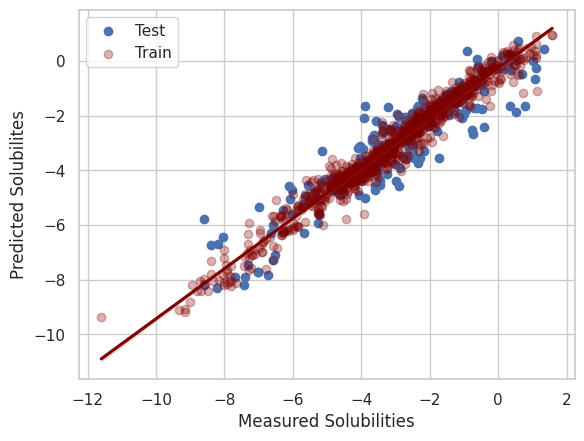

In [ ]:
plt.scatter(y_test, rf.predict(X_test), label='Test')
sns.regplot(x = y_train, y = rf.predict(X_train), color = 'maroon',scatter_kws={'alpha':0.3}, label='Train' )
plt.xlabel('Measured Solubilities')
plt.ylabel('Predicted Solubilites')
plt.legend();

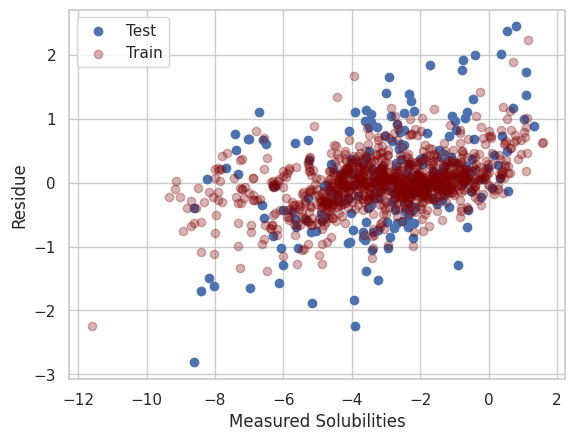

In [ ]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

plt.scatter(y_test, (y_test - y_pred_test), label='Test')
plt.scatter(y_train, (y_train - y_pred_train), c='maroon',label='Train', alpha = 0.3)
plt.xlabel('Measured Solubilities')
plt.ylabel('Residue')
plt.legend();

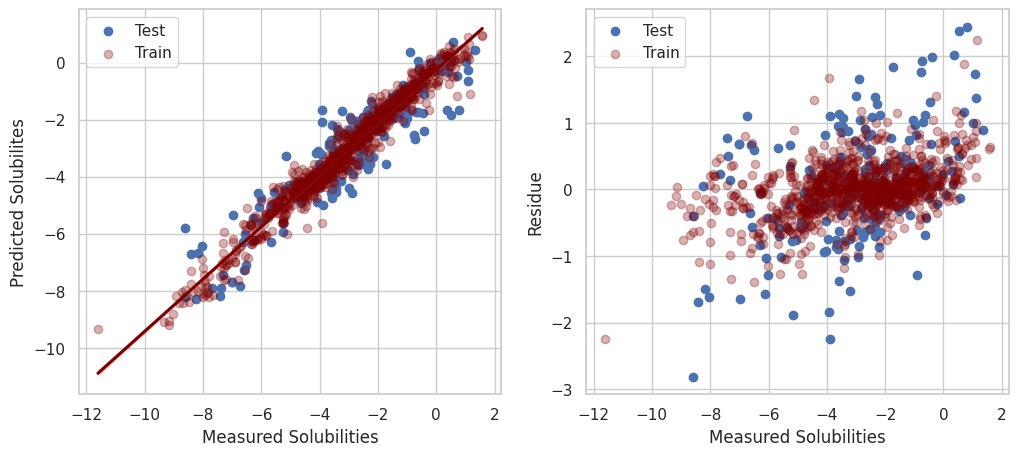

In [ ]:
plt.figure(figsize=(12,5))
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

plt.subplot(121)
plt.scatter(y_test, rf.predict(X_test), label='Test')
sns.regplot(x = y_train, y = rf.predict(X_train), color = 'maroon',scatter_kws={'alpha':0.3}, label='Train' )
plt.xlabel('Measured Solubilities')
plt.ylabel('Predicted Solubilites')
plt.legend();

plt.subplot(122)
plt.scatter(y_test, (y_test - y_pred_test), label='Test')
plt.scatter(y_train, (y_train - y_pred_train), c='maroon',label='Train', alpha = 0.3)
plt.xlabel('Measured Solubilities')
plt.ylabel('Residue')
plt.legend();
plt.savefig('vis.png', dpi=200, bbox_inches='tight')

In [ ]:
test.head()

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol
133,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl,-7.213,0,0.325,0.138,0.107,1882,149.405,-7.320
46,"1,4-Dichlorobenzene",Clc1ccc(Cl)cc1,-3.002,1,0.407,0.250,0.190,798,153.063,-3.270
849,Monotropitoside,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,1.634,0,0.260,0.099,0.073,1478,165.656,-0.742
1023,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-3.279,1,0.312,0.197,0.167,778,163.466,-2.620
513,"cis 1,2-Dichloroethylene",Cl\C=C/Cl,-1.117,1,0.613,0.500,0.415,652,159.957,-1.300


In [ ]:
test.reset_index(drop=True, inplace=True)

In [ ]:
test_ = pd.concat([test, pd.DataFrame(y_pred_test, columns=['test_predictions'])], axis=1)

In [ ]:
test_

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol,test_predictions
0,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl,-7.213,0,0.325,0.138,0.107,1882,149.405,-7.320,-7.458
1,"1,4-Dichlorobenzene",Clc1ccc(Cl)cc1,-3.002,1,0.407,0.250,0.190,798,153.063,-3.270,-3.124
2,Monotropitoside,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,1.634,0,0.260,0.099,0.073,1478,165.656,-0.742,-2.670
3,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-3.279,1,0.312,0.197,0.167,778,163.466,-2.620,-3.148
4,"cis 1,2-Dichloroethylene",Cl\C=C/Cl,-1.117,1,0.613,0.500,0.415,652,159.957,-1.300,-1.127
...,...,...,...,...,...,...,...,...,...,...,...
224,Lorazepam,OC3N=C(c1ccccc1Cl)c2cc(Cl)ccc2NC3=O,-5.064,1,0.363,0.215,0.163,1354,157.445,-3.604,-4.566
225,Formetanate,CNC(=O)Oc1cccc(N=CN(C)C)c1,-2.132,1,0.327,0.245,0.245,686,166.875,-2.340,-1.983
226,Terbacil,Cc1[nH]c(=O)n(c(=O)c1Cl)C(C)(C)C,-2.862,1,0.372,0.238,0.252,852,166.912,-2.484,-3.076
227,1-Napthol,Oc1cccc2ccccc12,-2.414,1,0.291,0.575,0.332,432,154.355,-2.220,-2.245


In [ ]:
test_['abs_res'] = abs(test_['Log_sol'] - test_['test_predictions']).round(2)

In [ ]:
test_.sort_values('abs_res', ascending=False, inplace=True)

In [ ]:
test_.head()

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol,test_predictions,abs_res
113,Etofenprox,CCOc1ccc(cc1)C(C)(C)COCc3cccc(Oc2ccccc2)c3,-7.051,0,0.214,0.242,0.062,1120,158.998,-8.600,-5.785,2.810
167,Sucrose,OCC2OC(OC1(CO)OC(CO)C(O)C1O)C(O)C(O)C2O,3.675,0,0.275,0.096,0.055,1158,169.549,0.790,-1.656,2.450
195,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,-1.864,1,0.349,0.178,0.249,1262,167.514,0.523,-1.854,2.380
159,Thiram,CN(C)C(=S)SSC(=S)N(C)C,-0.634,1,0.377,0.417,0.168,1350,159.649,-3.900,-1.655,2.240
97,Maltose,OCC1OC(OC2C(O)C(O)C(O)OC2CO)C(O)C(O)C1O,4.251,0,0.275,0.096,0.052,1158,169.549,0.358,-1.656,2.010


In [ ]:
PandasTools.AddMoleculeColumnToFrame(test_,'SMILES','Mol',includeFingerprints=False)


In [ ]:
test_.head()

,Compound ID,SMILES,FilterItLogS,Lipinski,SIC0,RNCG,RPCG,ATS0Z,AATS0i,Log_sol,test_predictions,abs_res,Mol
113,Etofenprox,CCOc1ccc(cc1)C(C)(C)COCc3cccc(Oc2ccccc2)c3,-7.051,0,0.214,0.242,0.062,1120,158.998,-8.600,-5.785,2.810,<rdkit.Chem.rdchem.Mol object at 0x79b0f41e5e70>
167,Sucrose,OCC2OC(OC1(CO)OC(CO)C(O)C1O)C(O)C(O)C2O,3.675,0,0.275,0.096,0.055,1158,169.549,0.790,-1.656,2.450,<rdkit.Chem.rdchem.Mol object at 0x79b0f41e5ee0>
195,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,-1.864,1,0.349,0.178,0.249,1262,167.514,0.523,-1.854,2.380,<rdkit.Chem.rdchem.Mol object at 0x79b0f41e5f50>
159,Thiram,CN(C)C(=S)SSC(=S)N(C)C,-0.634,1,0.377,0.417,0.168,1350,159.649,-3.900,-1.655,2.240,<rdkit.Chem.rdchem.Mol object at 0x79b0f41e5fc0>
97,Maltose,OCC1OC(OC2C(O)C(O)C(O)OC2CO)C(O)C(O)C1O,4.251,0,0.275,0.096,0.052,1158,169.549,0.358,-1.656,2.010,<rdkit.Chem.rdchem.Mol object at 0x79b0f41e6030>


In [ ]:
img=Draw.MolsToGridImage(test_['Mol'][:5],molsPerRow=4,subImgSize=(200,200),legends=['Absolute error=' + str(x) for x in test_['abs_res'][:5]])

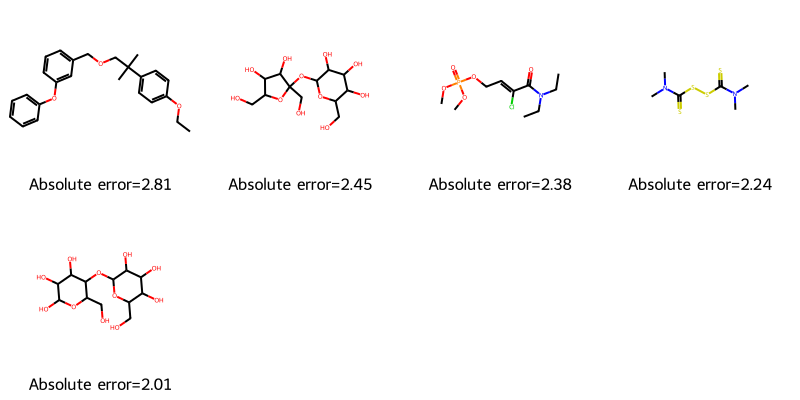

In [ ]:
img

In [ ]:
img=Draw.MolsToGridImage(test_['Mol'][-5:],molsPerRow=4,subImgSize=(200,200),legends=['Absolute error=' + str(x) for x in test_['abs_res'][-5:]])

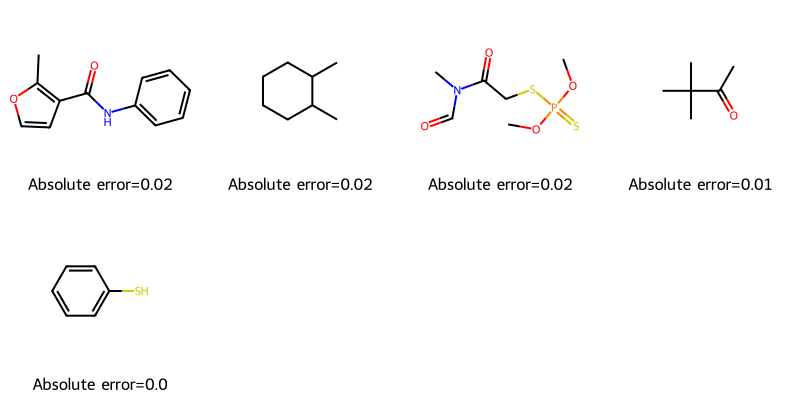

In [ ]:
img

## **Explainability**
https://youtu.be/Q0B4lp1d48s